# Time-Series-Momentum -- does an asset's own trend predict its next month?
### Moskowitz-Ooi-Pedersen (2012) 'trend everywhere', tested honestly on a cross-asset basket

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Vol_scaling_vs_equal_notional%3F: Confirmed](https://img.shields.io/badge/Vol_scaling_vs_equal_notional%3F-Confirmed-8b949e?style=flat-square)

In 2012, Tobias Moskowitz, Yao Hua Ooi and Lasse Pedersen published *Time Series Momentum*: forget ranking assets against each other -- just look at whether an asset has been going **up or down over the past year**, and bet it keeps going that way. Buy what's rising, short what's falling, and do it across **everything** -- stocks, bonds, commodities, currencies, gold. Risk-balance the bets, and the diversified book printed a high Sharpe with famous **crisis alpha** in 2008.

We replicate that recipe on a **12-ETF cross-asset basket** and ask the honest question: does it still pay on a small, modern basket, net of real costs?

> **This is the plain-language layer.** Want the HAC *t*-stats, the sign-shuffle placebo and the lookback-fragility sweep? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from time_series_momentum import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return os.path.exists(os.path.join(study, "_cache", "tsmom_prices.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices = data.drop_partial_last_month(data.fetch_panel())
    mp = st.to_monthly(prices)
    bk_v = st.tsmom_book(mp, vol_scale=True)
    bk_e = st.tsmom_book(mp, vol_scale=False)
    sv = st.summary(bk_v["port_gross"]); se = st.summary(bk_e["port_gross"])
    print(f"Vol-scaled TSMOM: {sv['mean']*100:+.2f}%/yr  HAC t={sv['tstat']:+.3f}")
    print(f"Equal-notional  : {se['mean']*100:+.2f}%/yr  HAC t={se['tstat']:+.3f}")


yfinance cache present: True


Vol-scaled TSMOM: +3.09%/yr  HAC t=+1.611
Equal-notional  : +1.54%/yr  HAC t=+0.788


## The answer first

| Question | Answer |
|---|---|
| Does own-trend predict the next month? | **Sort of.** The vol-scaled book earns **+3.09%/yr** at HAC *t* = **+1.611** -- positive and the placebo says it's *real structure* (*p* = 0.005), but the *t* is below the desk's bar of 2. |
| Is it robust? | **Not quite.** Change the lookback and the *t* swings 2.02 (9m) -> 1.61 (12m) -> 0.45 (15m). It straddles the bar. |
| Could you trade it? | **Barely.** Net **+2.68%/yr** at a 0.34 Sharpe with a -19% drawdown -- positive, but thin and it needs persistent shorting and 12-asset diversification. |
| Does risk-balancing matter? | **Yes -- a lot.** Vol-scaling roughly doubles the Sharpe (0.39 vs 0.20) vs a naive sign book. |

> The big story: trend showed up best when it mattered -- **+4.8% in 2008** while stocks collapsed, **+10.3% in 2022** in the rates/commodity trend -- but it bled in choppy years (-18% in 2018). Real-looking, thin, and regime-dependent.

## 1 -- The claim

> *"We document significant time series momentum in equity index, currency, commodity, and bond futures... A diversified portfolio of time series momentum strategies across all asset classes delivers substantial abnormal returns."*

-- Moskowitz, Ooi & Pedersen (2012), *Journal of Financial Economics*

The recipe: at each month-end, take the **sign of each asset's own trailing 12-month return** (+1 up, -1 down). Size each bet inverse to its recent volatility (so a calm bond and a wild commodity risk the same), and average across the whole basket. Hold a month, repeat.

## 2 -- So what?

Time-series momentum is the engine behind the **managed-futures / CTA** industry -- tens of billions of dollars of 'trend-following' funds. Its selling point is *crisis alpha*: when a crash drags on, trend goes short and profits while everything else bleeds. If that premium has **decayed** on a small modern basket, a lot of 2-and-20 product is selling a 2012 backtest the recent data barely supports.

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **No look-ahead.** The 12-month sign uses only past prices; the vol estimate that sizes next month uses only past data. We form on the month-end close and earn the *next* month -- one forward execution lag, no same-bar fill.
2. **A placebo null.** We randomly flip each asset's position sign and recompute the book 1,000+ times. If the real edge is no better than coin-flip signs, it's noise.
3. **Name the survivorship bias on the *signal* axis.** The basket is ETFs that *survived* to 2026 -- though, unlike a stock momentum short, a falling ETF here is simply *shorted*, never deleted, so the bias is much milder.

## 4 -- The teardown

**First, does the trend engine work when the trend is planted?**

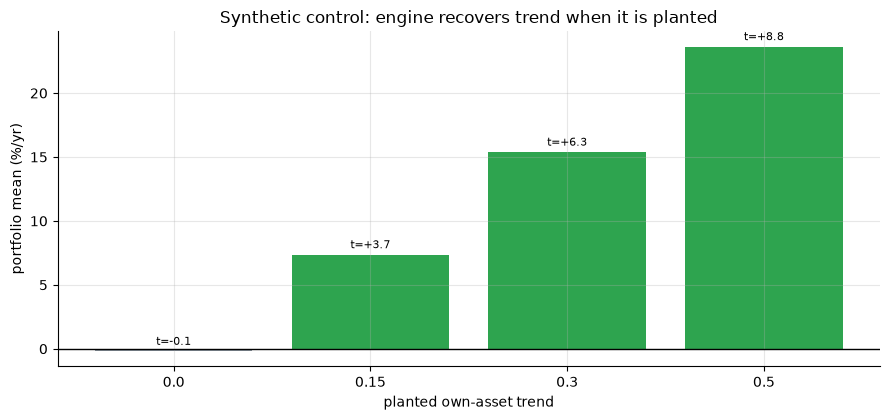

 trend_strength  port_mean_ann  tstat   n
           0.00         -0.002 -0.131 107
           0.15          0.074  3.661 107
           0.30          0.154  6.306 107
           0.50          0.236  8.801 107


In [2]:
ctrl = st.synthetic_control()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if t > 2 else GREY for t in ctrl['tstat']]
ax.bar(ctrl['trend_strength'].astype(str), ctrl['port_mean_ann']*100, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['port_mean_ann']*100, ctrl['tstat'])):
    ax.text(i, m + 0.5, f't={t:+.1f}', ha='center', fontsize=8)
ax.set_xlabel('planted own-asset trend'); ax.set_ylabel('portfolio mean (%/yr)')
ax.set_title('Synthetic control: engine recovers trend when it is planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: it finds trend when it's planted and (across 20 seeds) scores a null *t* of **-0.31** when it isn't. So the verdict on the real tape reflects **the market**, not the method.

**Now the honest test on the real basket -- and does risk-balancing help?**

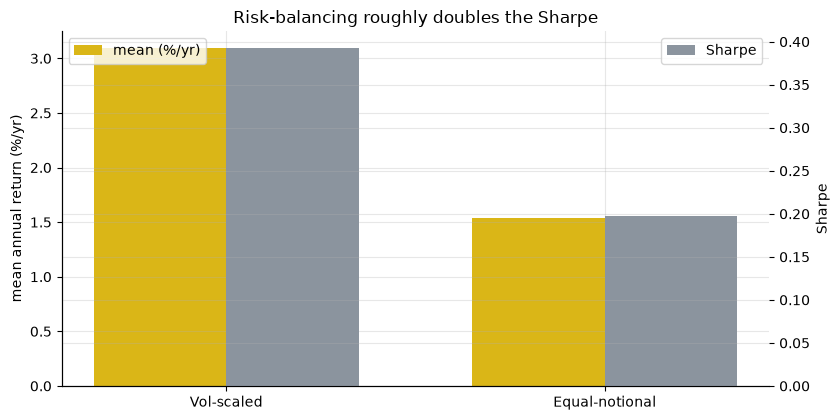

Vol-scaled : +3.09%/yr  Sharpe +0.39
Equal-notn : +1.54%/yr  Sharpe +0.20


In [3]:
if HAVE_REAL:
    vs_g = sv['mean']*100; vs_sh = sv['sharpe']
    en_g = se['mean']*100; en_sh = se['sharpe']
else:
    vs_g, vs_sh = 3.09, 0.392
    en_g, en_sh = 1.54, 0.198

fig, ax = plt.subplots(figsize=(8.5, 4.3))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, [vs_g, en_g], w, color=AMBER, label='mean (%/yr)')
ax2 = ax.twinx()
ax2.bar(x + w/2, [vs_sh, en_sh], w, color=GREY, label='Sharpe')
ax.set_xticks(x); ax.set_xticklabels(['Vol-scaled', 'Equal-notional'])
ax.set_ylabel('mean annual return (%/yr)'); ax2.set_ylabel('Sharpe')
ax.set_title('Risk-balancing roughly doubles the Sharpe')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()
print(f'Vol-scaled : {vs_g:+.2f}%/yr  Sharpe {vs_sh:+.2f}')
print(f'Equal-notn : {en_g:+.2f}%/yr  Sharpe {en_sh:+.2f}')

Vol-scaling lifts the Sharpe from **~0.20** to **~0.39** and halves the drawdown. That is the Moskowitz-Ooi-Pedersen insight made visible: letting a calm bond and a wild commodity each carry the *same risk* is what turns own-asset trend into a diversified premium instead of an equity-beta proxy.

## 5 -- The verdict

- **Signal -- WEAK.** Vol-scaled TSMOM earns +3.09%/yr at HAC *t* = +1.611 with placebo *p* = 0.005. The placebo says the trend link is *real structure*, but the canonical 12-month *t* doesn't clear the desk's bar of 2, and it wobbles with the lookback (2.02/1.61/0.45). Strong literature plus a sub-2 *t* = WEAK, never REAL.
- **Tradability -- FRAGILE.** Net **+2.68%/yr** at a 0.34 Sharpe with a -19% drawdown -- positive, but thin and it needs persistent shorting + diversification.
- **Vol-scaling vs equal-notional -- CONFIRMED.** Risk-balancing roughly doubles the Sharpe. The method choice matters more than the raw signal.

## 6 -- Could you actually trade it?

Marginally. The net number is genuinely positive -- rare on this desk -- but:

1. **Shorting.** The book is short ~50% of NAV on average; that costs borrow (we charge 50bps/yr) and carries recall risk.
2. **Leverage & breadth.** Inverse-vol sizing levers up calm bond/FX legs, and the edge leans on holding *all 12* asset classes -- a retail book can't cheaply do that.
3. **The drawdown.** A -19% loss and a sign that flips year to year (+17% 2017 -> -18% 2018) -- trend's choppy-market tail.
4. **The sub-2 *t*.** With significance below the bar, the live edge could be smaller still.

## 7 -- Going further

- **The cross-sectional cousin.** [Study 507 -- Cross-Sectional-Momentum](../../507-cross-sectional-momentum/) ranks assets *against each other* instead of against their own history.
- **SMA trend timing.** [Study 110 -- Faber-Timing](../../110-faber-timing/) is the long-or-flat, single-asset price-vs-average cousin.
- **A century of trend.** Hurst-Ooi-Pedersen (2017) push time-series momentum back to 1880 -- and document the post-2009 'trend drought' that thins these numbers.

*Think trend survives on a realistic basket net of costs? Fork this, add managed-futures-style breadth (more assets, futures not ETFs), and show *t* > 2 net of borrow. That is the bar.*